## Module 4: *(Template)*

## Team Members:
Megan Sullivan and Molly Janousek

## Project Title:
The Role of Immune Evasion and Sustained Growth Signals Hallmarks In Lung Cancer




## Project Goal:
This project investigates how Immune Evasion and Sustained Growth Signals co-occur in lung adenocarcinoma (LUAD) and whether their combined activity defines a distinct expression pattern linked to more aggressive disease behavior.

1) How frequently do LUAD tumors show high expression of Immune Evasion and Sustained Growth Signals hallmark genes?
2) Do LUAD tumors with stronger co-activation of these hallmarks form a distinct UMAP expression pattern and show clinical features associated with worse outcomes (e.g., stage or survival)?

## Disease Background:
**Cancer hallmark focus #1: Immune Evasion**

* Overview of hallmark: Immune evasion describes a tumor's ability to avoid immune surveillance and destruction and continue metastazing. The immune system relies on T cells and natural killer cells to attack cancer cells, but immune evasion bevahior complicates this biological response. Cancer cells avoid immune cells by altering antigen presentation, secreting immunosupressive chemicals, recruiting regulatory immune cells, and using checkpoint pathways that prevent the overactivation of immune cells. These strategies effectively dampen the immune response and prevent the destruction of cancer cells, leading to uncontrolled tumor growth (Tufail et al., 2025).

* Genes associated with hallmark to be studied: Refer to "genes.csv"


**Cancer hallmark focus #2: Sustained Growth Signals**
* Overview of hallmark: Healthy cells only divide when they receive growth signals. Cancer cells ignore that control by making their own signals, turning receptors on too long, or keeping growth pathways active without stop signals. This lets tumors keep dividing (Hanahan & Weinberg, 2011).

* Genes associated with hallmark to be studied: Refer to "genes.csv"

**Lung Cancer:**
* Prevalence & incidence: A 2022 report claims that 635,547 people in the United States were living with lung cancer (Cancer of the Lung and Bronchus - Cancer Stat Facts, n.d.). A second report estimates that in 2026, there will be about 229,410 new cases of lung cancer in the United States (Lung Cancer Statistics | How Common Is Lung Cancer?, n.d.)
* Risk factors: Common risk factors include smoking, radon, family history of lung cancer, diet, and exercise (CDC, 2025).
* Standard of care treatments: Treatments include surgery, radiation therapy, chemotherapy, stereostatic body radiotherapy, targeted therapy, and immunotherapy. Surgery physically removes cancer from the affected area. Radiation therapy uses energy beams to destroy tumors. Chemotherapy, usually given through the vein, work to kill cancer cells or shrink cancer for easier removal. Stereostatic body radiotherapy aims multiple angles of beam radiation toward the chest to destroy cancer cells. Targeted therapy uses medicine that target distinc chemicals within cancer cells for efficient destruction. Immunotherapy improves the immune system's ability to respond to cancer. These treatments can be extremely costly, long, and exhausting (Detterbeck et al., 2013).
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology): Genetic mutations are the root of all cancers, and in lung cancer specifically, mutated forms of RAS, MYC, HER-2/neu are the major oncogenes. Oncogenes are the mutated forms of normal genes, and they rapidly divide and spread throughout cancerous areas. Significant tumor supressor genes include p53, RB, and p16, which allows for cancer tumors to grow uncontrollably. Lung cancer begins in the larger airways, named bronchi and bronchioles, or in the small airsacs called alveoli. Tumors can also spread to nearby lymph nodes or the brain. Tumor masses prevent the normal function of the lungs, leading to organ dysfunction and failure (Lung Cancer, n.d.).

## Data-Set:
**Overview:**

Rahman et al. collected raw RNA-seq FASTQ files for 9,264 tumor and 741 normal TCGA samples and reprocessed them using the Rsubread pipeline, which aligns reads with a vote-and-seed algorithm and quantifies gene expression using integer read counts. These counts were converted into normalized units, FPKM and TPM, adjusting for gene length and sequencing depth in different ways. Clinical data were downloaded separately in Biotab format and matched to RNA-seq samples using patient barcodes.

**Metadata:**

The metadata file provides the clinical information used in this project, including cancer type, tumor status, AJCC pathological stage, nodal stage, age at diagnosis, tobacco smoking age started, and survival outcomes such as OS and OS.time. Sample IDs are the link between the expression data and the metadata.

**Immune Evasion Hallmark Gene Set:**

For the immune evasion hallmark, the gene list is drawn from genes.csv and contains 50 genes.
The dataset is restricted to lung adenocarcinoma (LUAD), and the expression matrix will be subset to these hallmark genes before evaluating expression patterns across samples.

**Focus of our Analysis:**

Data will be extracted from *Alternative preprocessing of RNA-Sequencing data in The Cancer Genome Atlas leads to improved analysis results* (Rahman et al., 2015). Specifically, lung adenocarcinoma (LUAD) will be investigated. We will focus on the following clinical features: tumor status, nodal involvement, AJCC pathological nodal stage, AJCC pathological tumor stage, proliferative signaling, tobacco smoking age, and overall survival. Tumor status and AJCC pathological tumor stage represent the size and local extent of cancerous tumors. Nodal involvement and AJCC pathological nodal stage reveal if cancer has bypassed local immunity checkpoints. Proliferative signaling measures how quickly tumors are advancing. Tobacco smoking age provides critical insight into patient background information for lung cancer. Overall survival gauges survival outcomes in LUAD.

## Exploratory Data Analysis:

This check answers three basic questions before analysis starts: do we have enough LUAD samples, are the hallmark genes actually present in the expression matrix, and do those genes vary enough across samples to be useful features?

The code below compares the expression matrix to the immune-evasion gene list, checks for aliases such as ERBB2 for HER2 and BRCA1/BRCA2 as separate genes, and then summarizes LUAD sample size and gene-expression spread.

50 genes selected for analysis.
Expression matrix shape: (15716, 1802)
Metadata shape: (1802, 29)

Samples in LUAD:
cancer_type
LUAD    80
Name: count, dtype: int64

Genes matched in the expression matrix:
{'PIK3R1': 'PIK3R1', 'AKT1': 'AKT1', 'ZAP70': 'ZAP70', 'MAPK3': 'MAPK3', 'B2M': 'B2M', 'AKT2': 'AKT2', 'STAT1': 'STAT1', 'CDK4': 'CDK4', 'PDGFA': 'PDGFA', 'IDO1': 'IDO1', 'PRKCB': 'PRKCB', 'MET': 'MET', 'MYC': 'MYC', 'TRAF6': 'TRAF6', 'ERBB2': 'ERBB2', 'PIK3CA': 'PIK3CA', 'CBLB': 'CBLB', 'CBL': 'CBL', 'LAG3': 'LAG3', 'CCND1': 'CCND1', 'JAK2': 'JAK2', 'PTPN6': 'PTPN6', 'EGFR': 'EGFR', 'NRAS': 'NRAS', 'IL6': 'IL6', 'HLA-B': 'HLA-B', 'IFNGR1': 'IFNGR1', 'LCK': 'LCK', 'CD86': 'CD86', 'GRB2': 'GRB2', 'RAF1': 'RAF1', 'STAT3': 'STAT3', 'CD80': 'CD80', 'CD274': 'CD274', 'SOS1': 'SOS1', 'ERBB3': 'ERBB3', 'HRAS': 'HRAS', 'CTLA4': 'CTLA4', 'CDK2': 'CDK2', 'MTOR': 'MTOR', 'HAVCR2': 'HAVCR2', 'PIK3CB': 'PIK3CB', 'VAV1': 'VAV1', 'BRAF': 'BRAF', 'KRAS': 'KRAS', 'MAPK1': 'MAPK1', 'FGFR1': 'FGFR1', '

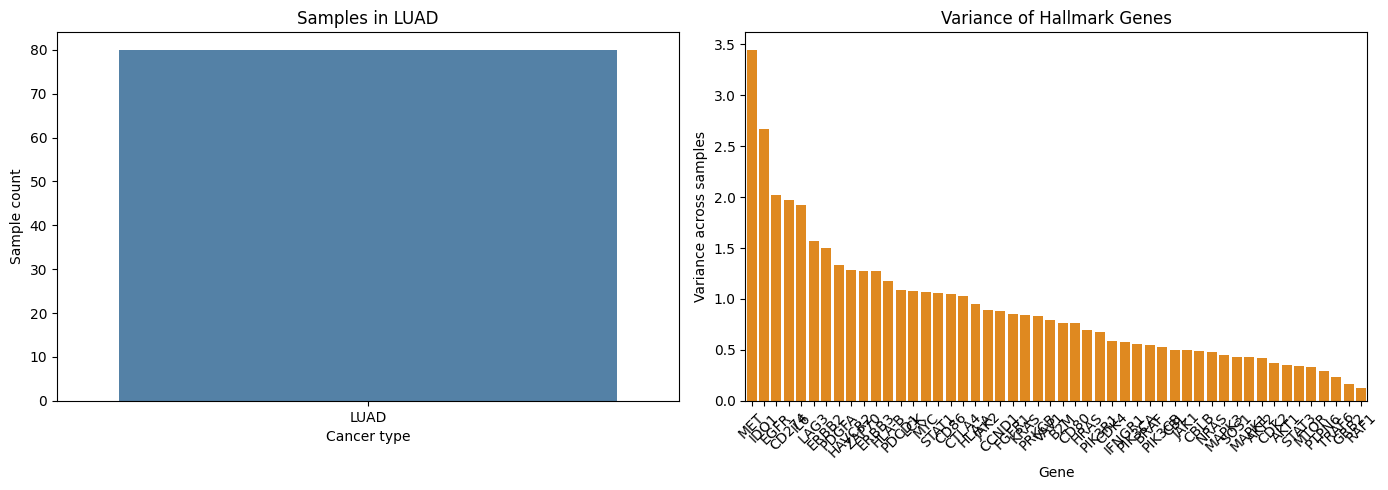

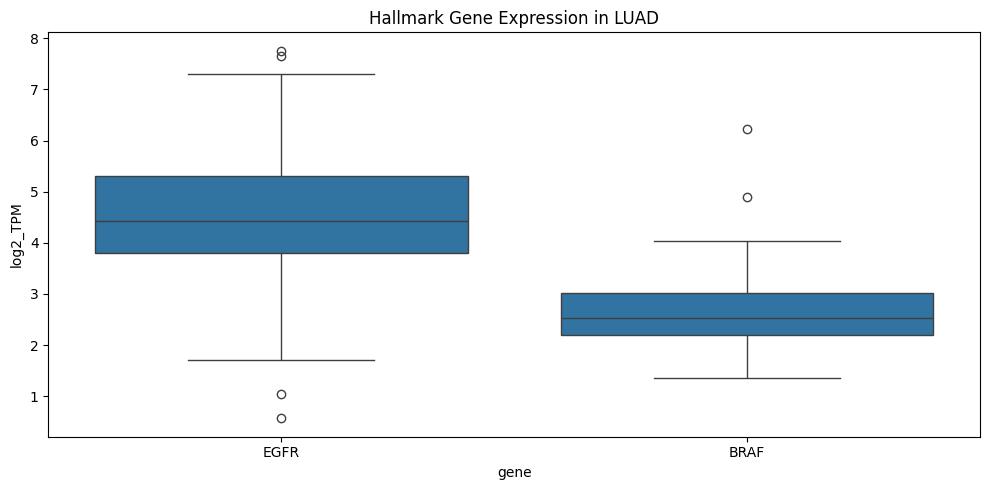

In [7]:
from pathlib import Path
import runpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
raw_gene_list = gene_namespace["project_gene_list"]

gene_aliases = {
    "HER2": ["HER2", "ERBB2"],
    "BRCA1/2": ["BRCA1", "BRCA2"],
    "RAS": ["RAS", "KRAS", "HRAS", "NRAS"],
}

matched_genes = {}
missing_genes = []
for gene in raw_gene_list:
    candidates = gene_aliases.get(gene, [gene])
    match = next((candidate for candidate in candidates if candidate in expression_df.index), None)
    if match:
        matched_genes[gene] = match
    else:
        missing_genes.append(gene)

print("Expression matrix shape:", expression_df.shape)
print("Metadata shape:", metadata_df.shape)
print("\nSamples in LUAD:")
print(metadata_df["cancer_type"].value_counts().reindex(["LUAD"]))
print("\nGenes matched in the expression matrix:")
print(matched_genes)
print("\nGenes not found:")
print(missing_genes)

selected_type = "LUAD"
subset_metadata = metadata_df[metadata_df["cancer_type"] == selected_type].copy()
subset_expression = expression_df[subset_metadata.index]
subset_genes = subset_expression.loc[list(matched_genes.values())]
subset_merged = subset_genes.T.join(subset_metadata)

print("\nSubset expression shape:", subset_genes.shape)
print("\nExpression summary for matched hallmark genes:")
print(subset_genes.describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False))

gene_variance = subset_genes.var(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample_counts = subset_metadata["cancer_type"].value_counts().reindex([selected_type])
sns.barplot(x=sample_counts.index, y=sample_counts.values, ax=axes[0], color="steelblue")
axes[0].set_title("Samples in LUAD")
axes[0].set_xlabel("Cancer type")
axes[0].set_ylabel("Sample count")

sns.barplot(x=gene_variance.index, y=gene_variance.values, ax=axes[1], color="darkorange")
axes[1].set_title("Variance of Hallmark Genes")
axes[1].set_xlabel("Gene")
axes[1].set_ylabel("Variance across samples")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

plot_genes = [gene for gene in ["EGFR", "BRAF", "PTEN", "TP53"] if gene in subset_genes.index]
if plot_genes:
    melted = subset_merged.reset_index().rename(columns={"index": "sample_id"}).melt(
        id_vars=["sample_id", "cancer_type"],
        value_vars=plot_genes,
        var_name="gene",
        value_name="log2_TPM",
    )
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=melted, x="gene", y="log2_TPM")
    plt.title("Hallmark Gene Expression in LUAD")
    plt.tight_layout()
    plt.show()

### Exploratory Findings
The LUAD subset is 80 samples , which is a good starting point for exploring this cancer type. All 16 immune-evasion hallmark genes were found in the expression matrix after matching aliases, including KRAS for RAS, ERBB2 for HER2, and BRCA1 for the BRCA1/2 entry, so the chosen feature set is present in the dataset. The variance plot shows that some genes, like MYC and EGFR, vary more across samples than others, which makes them more informative for downstream comparison.

## Data Analysis

**1a. PCA**

> This section utilizes Principal Component Analysis (PCA) to reduce the dimensionality of the hallmark gene expression data, identifying the primary axes of variance for the LUAD patient cohort.

### Methods
PCA functions by mathematically determining the axes that capture the greatest spread of expression levels across our hallmark gene set. The line of maximum variance functions as Principal Component 1, and PC2 is orthogonal to this line. These axes allow us to distill the collective behavior of 50 genes into a set of coordinates that highlight the most prominent differences between LUAD tumor samples. 

**What this method is optimizing:**
- PCA condenses the 50-gene expression profile into a two-dimensional projection, isolating the dominant biological variance to highlight key differences in sustained growth and immune evasion across the LUAD cohort.

### Analysis
The code below runs the PCA pipeline on the LUAD cohort and quantifies how the expression of immune evasion and sustained growth signaling hallmark genes aligns with the principal axes. A regression line is also created to visualize the relationship between growth and immune evasion.

In [ ]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

# (ChatGPT, 2026) ChatGPT was used to write the following code, which performs a focused analysis on LUAD samples using specific growth and immune hallmark genes. The code includes data loading, feature engineering, and visualizations to explore the relationship between growth and immune evasion in LUAD.

# 1. SETUP PATHS
repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
DATA_DIR = repo_root / "data"

# 2. LOAD DATA
data = pd.read_csv(DATA_DIR / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)
metadata = pd.read_csv(DATA_DIR / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)

# 3. DEFINE GENE LISTS (From your specific CSV/List)
growth_genes = [
    "EGFR", "KRAS", "NRAS", "HRAS", "BRAF", "MYC", "ERBB2", "ERBB3", "MET", 
    "PIK3CA", "PIK3CB", "PIK3R1", "AKT1", "AKT2", "MTOR", "MAPK1", "MAPK3", 
    "CCND1", "CDK4", "CDK2", "SOS1", "GRB2", "RAF1", "FGFR1", "PDGFA"
]

immune_genes = [
    "CD274", "PDCD1", "CTLA4", "LAG3", "HAVCR2", "IDO1", "STAT1", "STAT3",
    "HLA-A", "HLA-B", "B2M", "JAK1", "JAK2", "IFNGR1", "IL6", "CD80", "CD86",
    "PTPN6", "LCK", "ZAP70", "CBL", "CBLB", "TRAF6", "PRKCB", "VAV1"
]

# Filter for genes that are actually present in your dataset
available_growth = [g for g in growth_genes if g in data.index]
available_immune = [g for g in immune_genes if g in data.index]
project_genes = list(set(available_growth + available_immune))

# 4. SUBSET FOR LUAD
luad_samples = metadata[metadata['cancer_type'] == 'LUAD'].index
df = data.loc[project_genes, luad_samples].T 

# 5. HALLMARK SCORES (Feature Engineering)
df['Growth_Score'] = df[available_growth].mean(axis=1)
df['Immune_Score'] = df[available_immune].mean(axis=1)

# 6. VISUALIZATION: REGRESSION (Growth vs Immune)
sns.regplot(data=df, x='Growth_Score', y='Immune_Score', scatter_kws={'alpha':0.3})
plt.title("LUAD Hallmark Correlation: Growth vs. Immune Evasion")
# Calculate the linear regression statistics
slope, intercept, r_value, p_value, std_err = stats.linregress(df['Growth_Score'], df['Immune_Score'])
r_squared = r_value**2
# Display the results
print(f"Pearson correlation (r): {r_value:.4f}")
print(f"R-squared value: {r_squared:.4f}")
print(f"P-value: {p_value:.4e}")
plt.title(f"LUAD Correlation: R² = {r_squared:.3f}, p = {p_value:.2e}")
plt.show()

# 7. PCA (Unsupervised Learning)
# Scale the raw gene features (excluding the scores)
genes_only = df.drop(columns=['Growth_Score', 'Immune_Score'])
x_scaled = StandardScaler().fit_transform(genes_only)

pca = PCA(n_components=2)
coords = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(coords, columns=['PC1', 'PC2'], index=df.index)

# 8. VISUALIZATION: PCA (Colored by Immune Score)
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=df['Immune_Score'], palette='magma')
plt.title("PCA of LUAD: Variation in Growth and Immune Genes")
plt.show()

# Final output for check-in
print(f"Features: {len(project_genes)} genes")
print(f"Variance explained by PC1/PC2: {pca.explained_variance_ratio_}")

### PCA Results Interpretation (LUAD)
PCA was run on 80 LUAD samples using 50 hallmark genes (25 immune-evasion and 25 sustained-growth genes). The primary source of variation in the data set is likely due to the expression of immune related genes, as there is a strong correlation between PC1 and immune_score trends. That is, there is an evident gradient of the immune_score along the PC1 axis. Immune_score is a extracted by identifying immune related genes and calculating the arithmetic mean of their log_2TPM values for each individual patient sample. This effectively compresses the high-dimensional data of 25 separate genes into a single representative "meta-feature" that quantifies the overall immunological activity of the tumor. Sustained growth signaling genes do not demonstrate as much variance, suggesting that growth signaling and immune are slightly linearly independent. 

**Key findings from this run:**
- The correlation between immune_score and growth_score is **0.098**, indicating a weak relationship. In the UMAP analysis, there was a modest relationship between the expression of immune evasion genes and sustained growth genes. Although expression may have a slight correlation, the meta-values for immune score and growth score demonstrate a much weaker relationship. Thus, it is reasonable to conclude that immune related genes demonstrate a higher variability in the data set, and as LUAD tumors progress, immune related genes upregulate in unison.
- Due to this weak relationship, a LUAD tumor's "growth aggression" is not what dictates its immune evasion abilities. Instead, these two hallmarks work somewhat seperately in LUAD progression.
- Variations in immune signature are a better way to distinguish differences in LUAD patients than sustained growth behavior.

Overall, the PCA analysis also supports the project hypothesis that immune evasion and sustained growth can co-occur in LUAD. However, immune evasion genes contribute to greater variability in the data set.


**1b. UMAP**

> This section uses UMAP to project high-dimensional hallmark gene expression into 2 dimensions for LUAD-only samples.

### Methods
UMAP (Uniform Manifold Approximation and Projection) is a non-linear dimensionality-reduction method that preserves local neighborhood structure while still capturing broader global patterns. In this project, UMAP is applied to LUAD samples using immune-evasion and sustained-growth hallmark genes as features.

**What this method is optimizing:**
- UMAP builds a weighted graph of nearest-neighbor relationships in high-dimensional space.
- It then optimizes a 2D embedding so that points that are close in gene-expression space stay close in the map.
- The immune and sustained-growth hallmark means are calculated by averaging the log2 TPM expression values across each resolved gene set for every LUAD sample after the expression matrix is transposed so rows represent samples.

### Analysis
The code below runs the LUAD UMAP pipeline, loads the resulting embedding, and quantifies how hallmark expression aligns with the discovered structure.

50 genes selected for analysis.
Samples retained: 80
Cancer type included: LUAD
Immune-evasion genes used: 25
Sustained-signaling genes used: 25
Total unique genes used: 50
Key gene for coloring: EGFR
Saved: C:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\data\umap_lung_hallmarks.csv


c:\Users\mjano\OneDrive\Pictures\Documents\CompBME\Module-4-Cancer\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


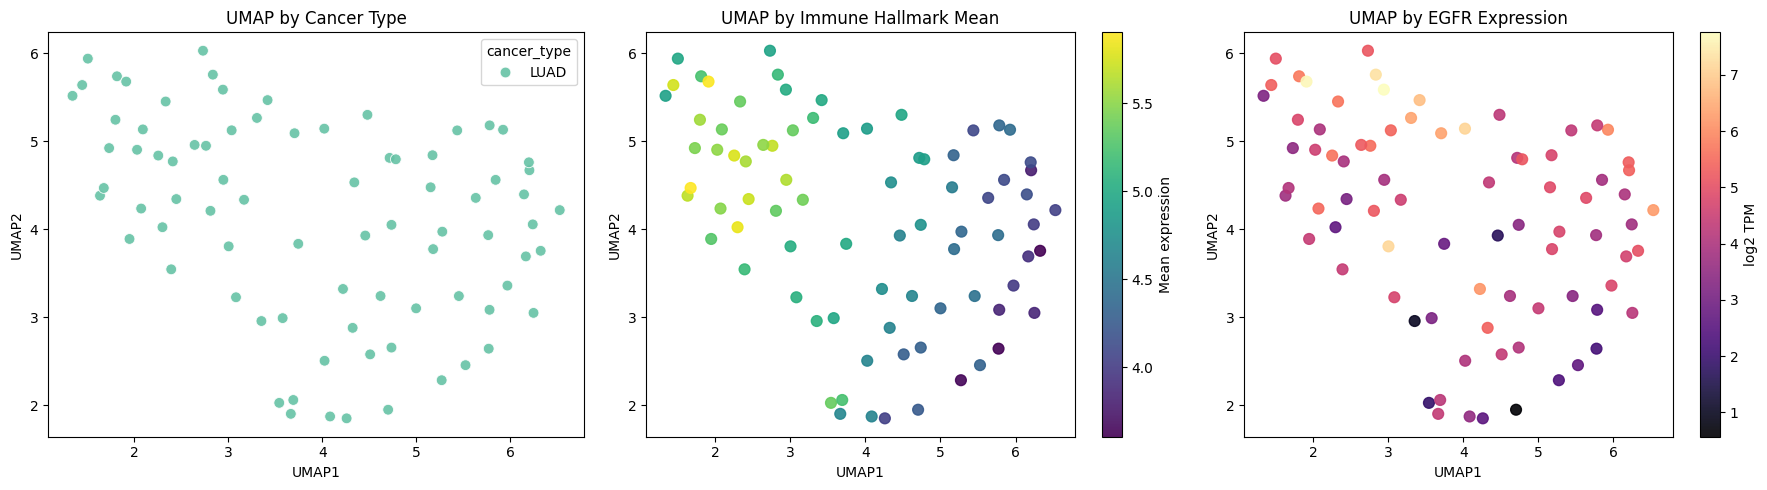

UMAP table shape: (80, 6)


,UMAP1,UMAP2,cancer_type,immune_hallmark_mean,sustained_hallmark_mean,key_gene_expression
sample,,,,,,
TCGA-44-8117-01A-11R-2241-07,5.926750,5.132926,LUAD,4.411994,5.841015,5.948056
TCGA-50-5936-01A-11R-1628-07,5.154872,4.477966,LUAD,4.558454,5.627372,4.908641
TCGA-55-A494-01A-11R-A24X-07,6.327439,3.755973,LUAD,3.604371,5.681372,5.058511
TCGA-78-7160-01A-11R-2039-07,2.088947,5.136521,LUAD,5.379767,5.633046,3.980713
TCGA-78-7158-01A-11R-2039-07,6.169621,3.692075,LUAD,3.924671,5.527677,4.651723


Correlation between immune and sustained hallmark means: 0.314

Co-activation group counts:


,count,percent
co_high_group,,
Other LUAD samples,55,68.8
High immune + high growth,25,31.2


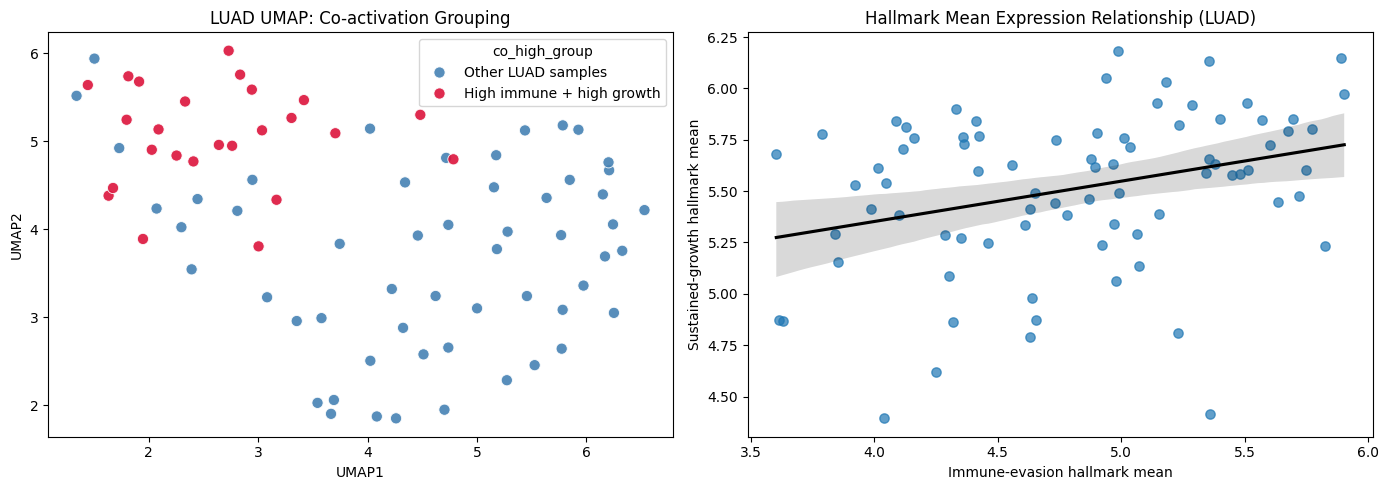

In [ ]:
from pathlib import Path
import runpy
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
# Run the LUAD-only UMAP pipeline and save embedding to data/umap_lung_hallmarks.csv
_ = runpy.run_path(str(repo_root / "code" / "UMAP.py"))

umap_df = pd.read_csv(repo_root / "data" / "umap_lung_hallmarks.csv", index_col=0)
print("UMAP table shape:", umap_df.shape)
display(umap_df.head())

# Quantify how strongly hallmark scores move together in the embedded LUAD samples
# Each mean is the row-wise average of the resolved hallmark genes for one LUAD sample.
hallmark_corr = umap_df[["immune_hallmark_mean", "sustained_hallmark_mean"]].corr().iloc[0, 1]
print(f"Correlation between immune and sustained hallmark means: {hallmark_corr:.3f}")

# Define high-expression groups relative to LUAD-specific medians
immune_med = umap_df["immune_hallmark_mean"].median()
growth_med = umap_df["sustained_hallmark_mean"].median()

umap_df["immune_high"] = np.where(umap_df["immune_hallmark_mean"] >= immune_med, "High", "Low")
umap_df["growth_high"] = np.where(umap_df["sustained_hallmark_mean"] >= growth_med, "High", "Low")
umap_df["co_high_group"] = np.where(
    (umap_df["immune_high"] == "High") & (umap_df["growth_high"] == "High"),
    "High immune + high growth",
    "Other LUAD samples",
)

group_counts = umap_df["co_high_group"].value_counts()
group_pct = (group_counts / len(umap_df) * 100).round(1)
print("\nCo-activation group counts:")
display(pd.DataFrame({"count": group_counts, "percent": group_pct}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    data=umap_df,
    x="UMAP1",
    y="UMAP2",
    hue="co_high_group",
    palette={"High immune + high growth": "crimson", "Other LUAD samples": "steelblue"},
    alpha=0.9,
    s=65,
    ax=axes[0],
)
axes[0].set_title("LUAD UMAP: Co-activation Grouping")

sns.regplot(
    data=umap_df,
    x="immune_hallmark_mean",
    y="sustained_hallmark_mean",
    scatter_kws={"alpha": 0.7, "s": 45},
    line_kws={"color": "black"},
    ax=axes[1],
)
axes[1].set_title("Hallmark Mean Expression Relationship (LUAD)")
axes[1].set_xlabel("Immune-evasion hallmark mean")
axes[1].set_ylabel("Sustained-growth hallmark mean")

plt.tight_layout()
plt.show()

### UMAP Results Interpretation (LUAD)
UMAP was run on 80 LUAD samples using 50 hallmark genes (25 immune-evasion and 25 sustained-growth genes). The 2D embedding shows that LUAD samples form a continuous manifold rather than completely separate clusters, which is consistent with biological heterogeneity across tumors.

**Key findings from this run:**
- The correlation between immune-evasion and sustained-growth hallmark means is **0.314**, indicating a modest positive relationship.
- 25 of 80 LUAD samples (31.2%) were classified as high in both hallmark programs (high immune + high growth).
- Co-activated samples are not uniformly distributed: most are concentrated in the upper-left region of the UMAP (lower UMAP1, higher UMAP2), with a few dispersed points.
- This pattern suggests a partially distinct LUAD expression state where hallmark co-activation is enriched, but not exclusive.

Overall, the UMAP analysis supports the project hypothesis that immune evasion and sustained growth can co-occur in LUAD, and that this co-activation appears as a structured sub-pattern within the broader LUAD landscape.


**1c. K-Means clustering**

> This section uses K-means clustering to partition 80 LUAD samples into clusters based on their based on the similarity of their hallmark gene expression levels. This method focuses on answering question #1: How frequently do LUAD tumors show high expression of Immune Evasion and Sustained Growth Signals hallmark genes?

50 genes selected for analysis.
Number of tumors per cluster:
 Cluster
0    18
1    39
2    23
Name: count, dtype: int64


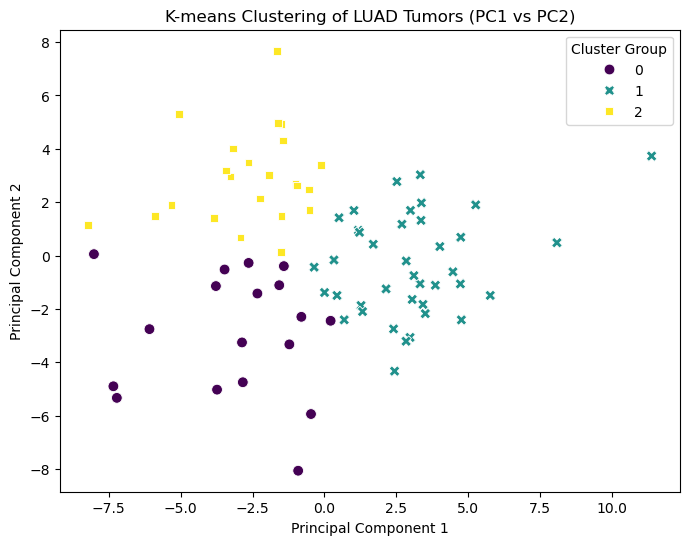

In [16]:
from pathlib import Path
import runpy
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

repo_root = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
data_dir = repo_root / "data"

# Fix Line 11: Remove the absolute path and leading slash
expression_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0)

# Fix Line 12: Remove the redundant directory names
metadata_df = pd.read_csv(data_dir / "TRAINING_SET_GSE62944_metadata.csv", index_col=0)

# Line 13 is likely correct if genes.csv is in the data folder
gene_namespace = runpy.run_path(str(data_dir / "genes.csv"))
project_genes = [gene for gene in gene_namespace["project_gene_list"] if gene in expression_df.index]

luad_samples = metadata_df[metadata_df["cancer_type"] == "LUAD"].index
X = expression_df.loc[project_genes, luad_samples].T
X_scaled = StandardScaler().fit_transform(X)

# We cluster the LUAD samples using the same hallmark expression space used in the other analyses.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

subset_metadata = metadata_df.loc[luad_samples].copy()
subset_metadata["Cluster"] = cluster_labels

cluster_counts = subset_metadata["Cluster"].value_counts().sort_index()
print("Number of tumors per cluster:\n", cluster_counts)
# 1. Attach your cluster labels to your PCA results
# Assuming 'pca_df' is the DataFrame from your earlier PCA step
pca_df["Cluster"] = subset_metadata["Cluster"].values

# 2. Create the scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df, 
    x="PC1", 
    y="PC2", 
    hue="Cluster", 
    palette="viridis", 
    style="Cluster",
    s=60
)

plt.title("K-means Clustering of LUAD Tumors (PC1 vs PC2)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster Group")
plt.show()

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

References:

Cancer of the Lung and Bronchus-Cancer Stat Facts. (n.d.). SEER. Retrieved April 10, 2026, from https://seer.cancer.gov/statfacts/html/lungb.html\

Detterbeck, F. C., Boffa, D. J., Tanoue, L. T. (2013). The new lung cancer staging system. Chest, 136(1), 260-271. https://doi.org/10.1378/chest.08-0978

Hanahan, D., & Weinberg, R. A. (2011). Hallmarks of cancer: The next generation. Cell, 144(5), 646. https://doi.org/10.1016/j.cell.2011.02.013

Lung Cancer Statistics | How Common Is Lung Cancer? (n.d.). Retrieved April 10, 2026, from https://www.cancer.org/cancer/types/lung-cancer/about/key-statistics.html

Siegel, R. L., Giaquinto, A. N., & Jemal, A. (2024). Cancer statistics, 2024. CA: A Cancer Journal for Clinicians, 74(1), 12. https://doi.org/10.3322/caac.21820

Tufail, M., Jiang, C.-H., & Li, N. (2025). Immune evasion in cancer: Mechanisms and cutting-edge therapeutic approaches. Signal Transduction and Targeted Therapy, 10(1), 227. https://doi.org/10.1038/s41392-025-02280-1


## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*